```text
Calibration analysis
├── Import & Setup
└── Runs on various calibration windows
```

# Calibration analysis

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.calibration import intercept_recalibration, PDCalibrator
from src.decisioning import compare_calibration_windows
from src.feature_engineering import create_target_def12
from src.metrics import my_metrics, my_threshold_metrics
from src.modelling import apply_pipe
from src.plots import my_calibration, my_calibration_comparison
from src.preprocessing import my_input_load, my_time_split

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# pipeline import

import joblib
pipeline_no_cali = joblib.load("../models/PIPELINE_ver_011_cal_none.pkl")
pipeline_sh_cali = joblib.load("../models/PIPELINE_ver_011_cal_shift-test.pkl")

In [4]:
# load input file

this_dataset = my_input_load(2016, 2021)

In [5]:
# CREATE TARGET VARIABLE

this_dataset, dr_summary = create_target_def12(this_dataset)

LoanDate range:     2016-01-01 00:00:00 2021-12-31 00:00:00
+12 months:         2017-01-01 00:00:00 2022-12-31 00:00:00
DefaultDate range:  2016-04-29 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2016,6023,1282,0.212851
2017,11109,2447,0.220272
2018,16946,2865,0.169066
2019,28487,4879,0.171271
2020,19959,2294,0.114936
2021,30266,3694,0.122051


In [6]:
# SPLIT TRAIN/TEST/OOT

windows = {"oot":  (2021, 2021)}

splits = my_time_split(this_dataset, "LoanYear", windows)

X_oot = splits["oot"]["X"]
y_oot = splits["oot"]["y"]

# SPLIT CALIBRATION WINDOWS: 5years/2years/1year

windows = {"lon": (2016, 2020), "mid":  (2019, 2020), "sho":  (2020, 2020)}

splits = my_time_split(this_dataset, "LoanYear", windows)

X_2016_2020 = splits["lon"]["X"]
y_2016_2020 = splits["lon"]["y"]
X_2019_2020 = splits["mid"]["X"]
y_2019_2020 = splits["mid"]["y"]
X_2020_2020 = splits["sho"]["X"]
y_2020_2020 = splits["sho"]["y"]


SPLIT SUMMARY

OOT
Years        : 2021 - 2021
Shape (X, y) : (30266, 105), (30266,)

LoanYear distribution
LoanYear
2021    30266
Name: count, dtype: int64

Default rate : 0.1221
------------------------------------------------------------

SPLIT SUMMARY

LON
Years        : 2016 - 2020
Shape (X, y) : (82524, 105), (82524,)

LoanYear distribution
LoanYear
2016     6023
2017    11109
2018    16946
2019    28487
2020    19959
Name: count, dtype: int64

Default rate : 0.1668
------------------------------------------------------------

MID
Years        : 2019 - 2020
Shape (X, y) : (48446, 105), (48446,)

LoanYear distribution
LoanYear
2019    28487
2020    19959
Name: count, dtype: int64

Default rate : 0.1481
------------------------------------------------------------

SHO
Years        : 2020 - 2020
Shape (X, y) : (19959, 105), (19959,)

LoanYear distribution
LoanYear
2020    19959
Name: count, dtype: int64

Default rate : 0.1149
---------------------------------------------------------

## Runs on various calibration windows

#### runs 

Run name: calibrated on 1yrs
----------------------------------------
applying pipeline...
EmploymentStatus: replacing 19,959 values of -1 with NaN
MaritalStatus: replacing 19,959 values of -1 with NaN
OccupationArea: replacing 19,959 values of -1 with NaN
UseOfLoan: replacing 19,959 values of -1 with NaN
----------------------------------------
training calibration...
Intercept shift (delta): -0.681076
----------------------------------------
BEFORE CALIBRATION
----------------------------------------
----------------------------------------
applying pipeline...
Education: replacing 3 values of -1 with NaN
EmploymentStatus: replacing 30,266 values of -1 with NaN
MaritalStatus: replacing 30,266 values of -1 with NaN
OccupationArea: replacing 30,266 values of -1 with NaN
UseOfLoan: replacing 30,266 values of -1 with NaN
----------------------------------------


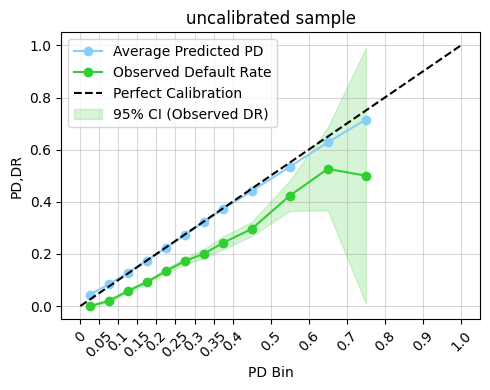

----------------------------------------
----------------------------------------
OOT (calibrated on 1yrs)
----------------------------------------
AUC         : 0.6814
KS          : 0.2598
Observed DR : 12.21%
Mean PD     : 21.08%
Brier       : 0.1101
Exposure    : 85,557,401
EL Total    : 11,192,523
EL Rate     : 13.08%
----------------------------------------
----------------------------------------
calibrating sample...
----------------------------------------
AFTER CALIBRATION
----------------------------------------
----------------------------------------


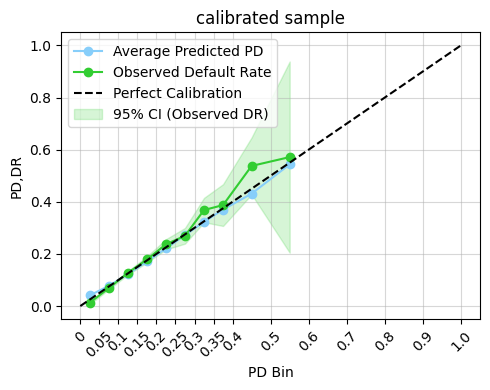

----------------------------------------
----------------------------------------
OOT (calibrated on 1yrs)
----------------------------------------
AUC         : 0.6814
KS          : 0.2598
Observed DR : 12.21%
Mean PD     : 12.22%
Brier       : 0.1019
Exposure    : 85,557,401
EL Total    : 6,609,820
EL Rate     : 7.73%
----------------------------------------
Run name: calibrated on 2yrs
----------------------------------------
applying pipeline...
EmploymentStatus: replacing 48,446 values of -1 with NaN
MaritalStatus: replacing 48,446 values of -1 with NaN
OccupationArea: replacing 48,446 values of -1 with NaN
UseOfLoan: replacing 48,446 values of -1 with NaN
----------------------------------------
training calibration...
Intercept shift (delta): -0.383305
----------------------------------------
BEFORE CALIBRATION
----------------------------------------
----------------------------------------
applying pipeline...
Education: replacing 3 values of -1 with NaN
EmploymentStatus: repl

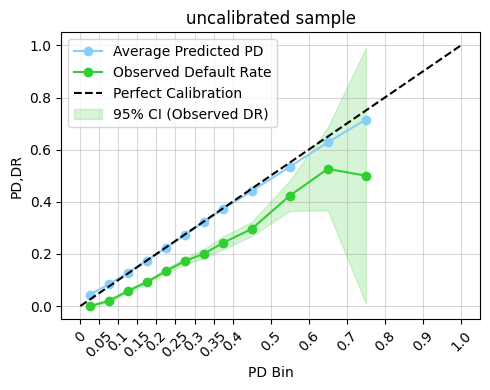

----------------------------------------
----------------------------------------
OOT (calibrated on 2yrs)
----------------------------------------
AUC         : 0.6814
KS          : 0.2598
Observed DR : 12.21%
Mean PD     : 21.08%
Brier       : 0.1101
Exposure    : 85,557,401
EL Total    : 11,192,523
EL Rate     : 13.08%
----------------------------------------
----------------------------------------
calibrating sample...
----------------------------------------
AFTER CALIBRATION
----------------------------------------
----------------------------------------


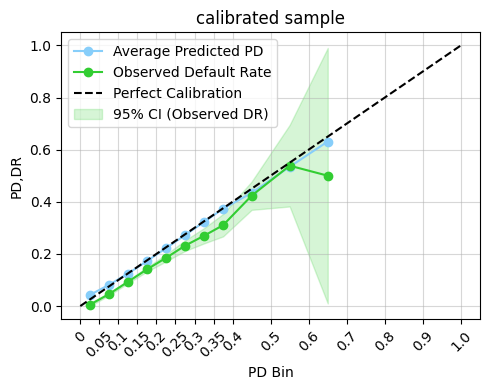

----------------------------------------
----------------------------------------
OOT (calibrated on 2yrs)
----------------------------------------
AUC         : 0.6814
KS          : 0.2598
Observed DR : 12.21%
Mean PD     : 15.64%
Brier       : 0.1030
Exposure    : 85,557,401
EL Total    : 8,394,183
EL Rate     : 9.81%
----------------------------------------
Run name: calibrated on 5yrs
----------------------------------------
applying pipeline...
Education: replacing 2 values of -1 with NaN
EmploymentStatus: replacing 72,715 values of -1 with NaN
HomeOwnershipType: replacing 2 values of -1 with NaN
MaritalStatus: replacing 72,715 values of -1 with NaN
OccupationArea: replacing 72,715 values of -1 with NaN
UseOfLoan: replacing 72,715 values of -1 with NaN
----------------------------------------
training calibration...
Intercept shift (delta): -0.216984
----------------------------------------
BEFORE CALIBRATION
----------------------------------------
-------------------------------

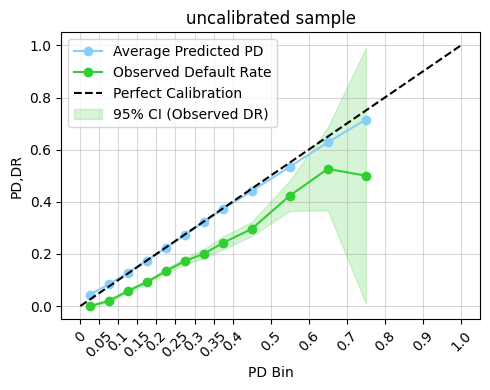

----------------------------------------
----------------------------------------
OOT (calibrated on 5yrs)
----------------------------------------
AUC         : 0.6814
KS          : 0.2598
Observed DR : 12.21%
Mean PD     : 21.08%
Brier       : 0.1101
Exposure    : 85,557,401
EL Total    : 11,192,523
EL Rate     : 13.08%
----------------------------------------
----------------------------------------
calibrating sample...
----------------------------------------
AFTER CALIBRATION
----------------------------------------
----------------------------------------


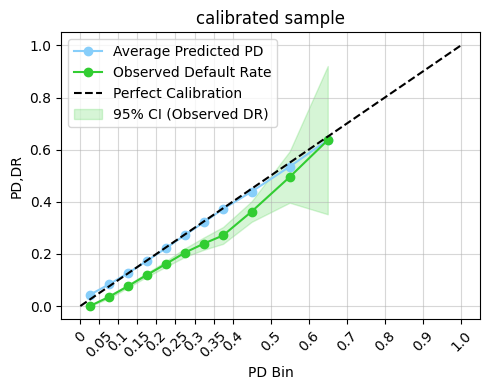

----------------------------------------
----------------------------------------
OOT (calibrated on 5yrs)
----------------------------------------
AUC         : 0.6814
KS          : 0.2598
Observed DR : 12.21%
Mean PD     : 17.85%
Brier       : 0.1051
Exposure    : 85,557,401
EL Total    : 9,538,349
EL Rate     : 11.15%
----------------------------------------


In [7]:
# LOOP ON VARIOUS CALIBRATION WINDOWS
# ----------------------------------------------------------
# each loop-step trains calibration on a predefined window
# and predicts/calibrates the oot sample 
# ----------------------------------------------------------
# calibration method: 'intercept_shift_test' "shift"  
#    2020-2020 Intercept shift (delta): -0.6810755371595716  
#    2019-2020 Intercept shift (delta): -0.38330530029264454
#    2016-2020 Intercept shift (delta): -0.21698419702798066

## setup calibration windows
windows = {
    "calibrated on 1yrs": {
        "X": X_2020_2020,
        "y": y_2020_2020,
    },
    "calibrated on 2yrs": {
        "X": X_2019_2020,
        "y": y_2019_2020,
    },
    "calibrated on 5yrs": {
        "X": X_2016_2020,
        "y": y_2016_2020,
    },
}

results = compare_calibration_windows(X_oot, y_oot, windows, pipeline_no_cali)


#### metrics comparison

In [10]:
# comparison of basic metrics

results_all = pd.DataFrame([
    results["calibrated on 1yrs"]["metrics_after"],
    results["calibrated on 2yrs"]["metrics_after"],
    results["calibrated on 5yrs"]["metrics_after"]
])
display(results_all.style.hide(axis="index"))

# apply PD threshold and compare metrics

my_threshold_metrics(y_oot, results["calibrated on 1yrs"]["predictions"]["PD"], 0.20, results["calibrated on 1yrs"]["predictions"]["Amount"], results["calibrated on 1yrs"]["predictions"]["EL"], dataset_name="OOT 2020_2020", verbose=True)
my_threshold_metrics(y_oot, results["calibrated on 2yrs"]["predictions"]["PD"], 0.20, results["calibrated on 2yrs"]["predictions"]["Amount"], results["calibrated on 2yrs"]["predictions"]["EL"], dataset_name="OOT 2019_2020", verbose=True)
my_threshold_metrics(y_oot, results["calibrated on 5yrs"]["predictions"]["PD"], 0.20, results["calibrated on 5yrs"]["predictions"]["Amount"], results["calibrated on 5yrs"]["predictions"]["EL"], dataset_name="OOT 2016_2020", verbose=True)


Dataset,AUC,KS,Observed_DR,Mean_PD,Brier,Exposure,EL_Total,EL_Rate
OOT (calibrated on 1yrs),0.681449,0.259812,0.122051,0.122246,0.101923,85557401.031400,6609819.995185,0.077256
OOT (calibrated on 2yrs),0.681449,0.259812,0.122051,0.156380,0.102991,85557401.031400,8394183.023960,0.098112
OOT (calibrated on 5yrs),0.681449,0.259812,0.122051,0.178499,0.105088,85557401.031400,9538349.020827,0.111485



OOT 2020_2020
--------------------------------------------------------------
Metric                               All         Threshold
--------------------------------------------------------------
Acceptance Rate                  100.00%            89.16%
Mean PD                           0.1222            0.1056
Exposure                      85,557,401        71,226,233
Mean Exposure                      2,827             2,639
EL                             6,609,820         4,506,906
EL Rate                            7.73%             6.33%
Implied LGD                       63.20%            59.91%
Default Rate                      12.21%            10.33%

OOT 2019_2020
--------------------------------------------------------------
Metric                               All         Threshold
--------------------------------------------------------------
Acceptance Rate                  100.00%            78.38%
Mean PD                           0.1564            0.1248
Exposure  

#### plot

prob_bin,Count,Defaults,Avg_PD_1,Avg_PD_2,Avg_PD_3,Observed_Default_Rate,CI_std,CI_lower,CI_upper,Share_of_Portfolio
"(0.0, 0.05]",46,0,0.035756,0.030446,0.022786,0.000000,0.000000,0.000000,0.000000,0.001520
"(0.05, 0.1]",1775,35,0.068329,0.058486,0.044104,0.019718,0.003300,0.013250,0.026186,0.058647
"(0.1, 0.15]",6509,377,0.105333,0.090676,0.068956,0.057920,0.002895,0.052245,0.063595,0.215060
"(0.15, 0.2]",7962,737,0.145384,0.125933,0.096661,0.092565,0.003248,0.086199,0.098931,0.263067
"(0.2, 0.25]",5882,788,0.187967,0.163908,0.127088,0.133968,0.004441,0.125263,0.142673,0.194343
"(0.25, 0.3]",3501,606,0.231716,0.203459,0.159447,0.173093,0.006394,0.160561,0.185626,0.115674
"(0.3, 0.35]",2001,402,0.277634,0.245564,0.194668,0.200900,0.008957,0.183344,0.218455,0.066114
"(0.35, 0.4]",1166,283,0.323078,0.287850,0.230871,0.242710,0.012555,0.218102,0.267318,0.038525
"(0.4, 0.5]",1103,326,0.388692,0.350095,0.285870,0.295558,0.013739,0.268629,0.322486,0.036444
"(0.5, 0.6]",279,118,0.480157,0.438994,0.367685,0.422939,0.029577,0.364969,0.480909,0.009218


----------------------------------------


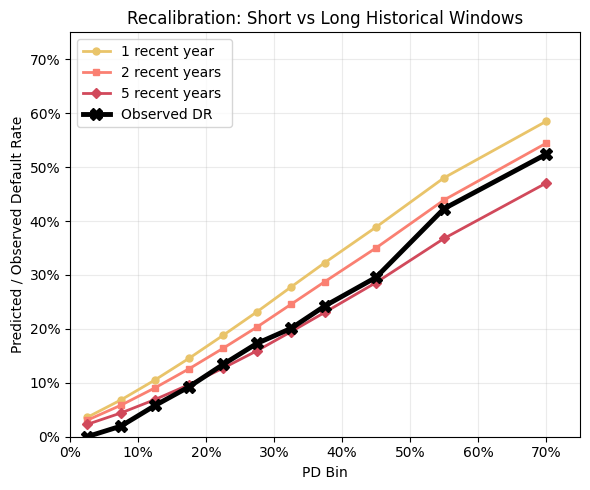

In [ ]:
# compare the 3 calibrations on raw pds

my_calibration_comparison(y_toot,
                          results["2016_2020"]["predictions"]["PD_raw"],
                          results["2016_2020"]["predictions"]["PD"], 
                          results["2019_2020"]["predictions"]["PD"], 
                          results["2020_2020"]["predictions"]["PD"]
                          )

#### W&B integration

In [ ]:
# log to W&B

# import wandb
# wandb.login()

# wandb.init(
#     project="my-credit-risk-model",
#     name="CALIBRATION WINDOW",
#     config={
#         "dataset": "OOT",
#         "calibration": "intercept_shift_test",
#         "window": "2016-2020"
#     }
# )

# wandb.log(metrics_toot)
# wandb.log({"Calibration Plot": wandb.Image(cal_plot_toot)})

# wandb.finish()